# Protocol 3: Correlating Assembly with IR Spectroscopy

This notebook follows the workflow behind Figure 3c of [Jirasek et al. (2024)](https://doi.org/10.1021/acscentsci.4c00120).

It correlates a physical observable, the number of infrared (IR) peaks, with the molecular assembly index across a dataset, and fits a linear model to estimate assembly index from IR peak count alone.

## The data

The spectra come from the Chemotion IR collection, which is **external data** and is not bundled with the repository.

> Jung, N., Tremouilhac, P., Punjabi, D., & Huang, P.-C. (2024). *Chemotion Repository - Data collection: FT-IR spectroscopy data (Chemotion IR)* [Data set]. Karlsruhe Institute of Technology. [doi:10.22000/OGoEQGlsZGElrgst](https://doi.org/10.22000/OGoEQGlsZGElrgst)

The collection is released under [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/). Cite it alongside Jirasek et al. (2024) in anything you publish from this notebook, and keep the attribution and licence on any spectra you redistribute or derive. BibTeX for both is in `att.bib` at the repository root (`jung2024chemotion`, `jirasek2024molecular`).

### 1. Download the archive

Open the DOI above and use **Download Dataset** on the RADAR4Chem landing page (47.5 MB, no account needed). You end up with a single archive named after the DOI — `10.22000-OGoEQGlsZGElrgst.tar` — holding 4183 JCAMP-DX (`.jdx`) spectra and one `meta_data.json`. Put it somewhere with room to spare beside it, since step 3 unpacks it in place. Compression is autodetected, so a `.tar.xz` works just as well.

### 2. Point this notebook at it

The `DATASET` parameter below reads the `CHEMOTION_IR_ARCHIVE` environment variable and falls back to a bare filename, so exporting the path before launching Jupyter is enough — no need to edit the notebook:

```bash
export CHEMOTION_IR_ARCHIVE=~/Downloads/10.22000-OGoEQGlsZGElrgst.tar
```

### 3. What the processing cell does

There is no manual preparation step: the first timed cell below calls `att.process_chemotion_ir_data(DATASET)`, which unpacks and parses everything for you. It

1. unpacks the archive into `chemotion_ir_data/` **beside the archive**, not beside this notebook;
2. reads `meta_data.json`, keeps the entries whose canonical SMILES RDKit can parse, and derives each one's spectrum `name` from its non-`.peak.jdx` identifier;
3. unpacks the nested `IR_data.tar.xz` into `IR_data/`, then loads every spectrum whose filename matches a surviving metadata name, in parallel across your cores;
4. merges the two on `name` and drops rows with any missing value.

What comes back is a DataFrame of three columns — `smiles`, `name` and `spectrum` — where each spectrum is an `(N, 2)` array of wavenumber and intensity. The same cell then narrows it to molecules of at most `MAX_BONDS` non-hydrogen bonds and drops spectra carrying non-finite intensities, which the Savitzky-Golay smoother in the step after cannot process.

Afterwards the archive's directory looks like this, and the unpacked copies are reused on later runs:

```text
10.22000-OGoEQGlsZGElrgst.tar
chemotion_ir_data/          <- created by step 1
├── meta_data.json
├── IR_data.tar.xz
└── IR_data/                <- created by step 3, holds the .jdx spectra
```

**Leave `save=False`.** Passing `save=True` writes a `chemotion_ir_data.csv.gz` cache into your *working* directory, and the next call short-circuits to it — but CSV has no array type, so the reloaded `spectrum` column comes back as strings and the filtering step fails. If you have such a file lying about, delete it before re-running.

## Running it

Run this notebook from its own directory so the figures it saves land beside
it. In JupyterLab:

```bash
cd examples/protocols/3
jupyter lab protocol_3.ipynb
```

Or headlessly, which is how the committed outputs were produced:

```bash
cd examples/protocols/3
jupyter nbconvert --to notebook --execute --inplace protocol_3.ipynb
```

Use **Run All** so the total-time cell at the end measures the whole workflow.

## Timing

The heavy steps below start with the `%%time` cell magic. Read the **Wall
time** it reports. The parallel steps spread work across every CPU core, and
`%%time` counts CPU time for the notebook's own process only, not the worker
pool, so wall time is the figure to compare. The times shown were
recorded on a 28-core machine and will differ on yours.

In [1]:
%matplotlib inline
import os
import time

import matplotlib.pyplot as plt
import numpy as np

import assemblytheorytools as att

print(f"CPU cores available: {os.cpu_count()}")
_t_start = time.perf_counter()

CPU cores available: 28


## Parameters

In [2]:
# Path to the Chemotion IR .tar archive (external data). Set CHEMOTION_IR_ARCHIVE
# or edit the fallback. A .tar.xz works too: tarfile autodetects the compression.
DATASET = os.environ.get("CHEMOTION_IR_ARCHIVE", "10.22000-OGoEQGlsZGElrgst.tar")

MAX_BONDS = 30            # keep molecules with at most this many non-hydrogen bonds
VIEW_IDX = 5              # which spectrum to visualise as the worked example
PEAK_RANGE = (1, 40)      # keep molecules whose spectra have this many peaks
PARAMS_0 = [0.5, 0.0]     # initial guess for the linear fit (slope, intercept)

# Assembly-index settings. No timeout is given, so calculate_assembly_index's
# default (100 s) applies; exact mode returns -1 on timeout.
AI_SETTINGS = {'strip_hydrogen': True, 'exact': True}

### 1. Data processing and filtering

Load and process the Chemotion IR dataset, then keep molecules with at most 30
non-hydrogen bonds. A few archived spectra carry non-finite intensity values
(`inf`), which the Savitzky-Golay smoother in the next step cannot process, so
we drop those rows here.

In [3]:
%%time
df = att.process_chemotion_ir_data(DATASET)
df = att.filter_by_nh_bonds(df, max_bonds=MAX_BONDS)

# Drop spectra whose intensity column contains inf/NaN; savgol_filter rejects
# non-finite input.
finite = df['spectrum'].apply(lambda s: np.all(np.isfinite(np.asarray(s).T[1])))
n_dropped = int((~finite).sum())
df = df[finite].reset_index(drop=True)
print(f"{len(df)} molecules after filtering ({n_dropped} dropped for non-finite spectra)")

Extracted data to chemotion_ir_data


1267 molecules after filtering (72 dropped for non-finite spectra)
CPU times: user 2.53 s, sys: 217 ms, total: 2.75 s
Wall time: 12.6 s


Smooth every spectrum with a Savitzky-Golay filter, in parallel.

In [4]:
%%time
df['spectrum'] = att.mp_calc(att.apply_sg_filter, df['spectrum'])

CPU times: user 125 ms, sys: 59.7 ms, total: 185 ms
Wall time: 1.98 s


### 2. Single-molecule visualisation

For one example molecule, find its IR peaks and plot the spectrum. Peak finding
runs over the 400-1500 cm⁻¹ fingerprint region after the smoothing above.

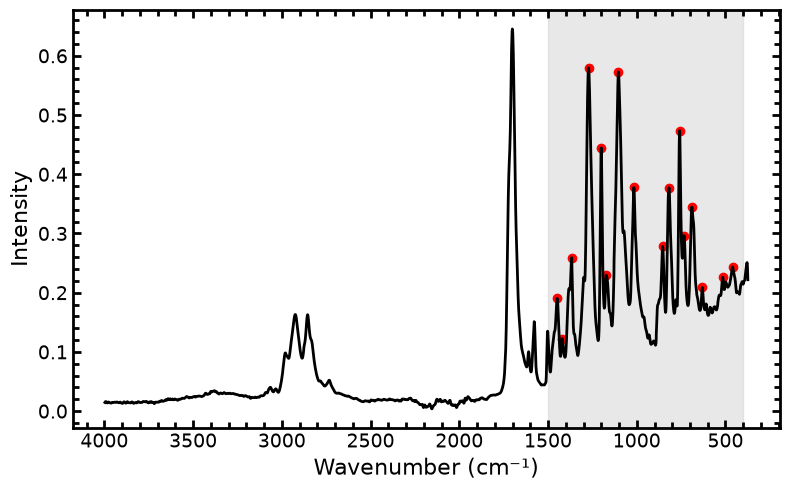

In [5]:
peaks = att.find_peak_indices_in_range(df['spectrum'].iloc[VIEW_IDX])

fig, ax = att.plot_ir_spectrum(df['spectrum'].iloc[VIEW_IDX], peaks=peaks)
plt.savefig("example_ir_spectrum.svg")
plt.savefig("example_ir_spectrum.png", dpi=300)
plt.show()

*The IR spectrum of the example molecule with its identified peaks.*

Render the same molecule's 3D structure for reference.

SMILES: CCOC(=O)c1ccc(cc1)C=O


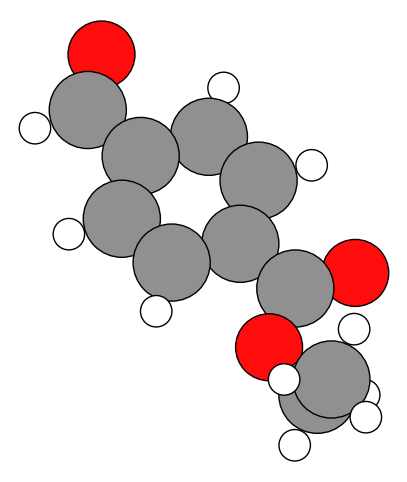

In [6]:
smi = df['smiles'].iloc[VIEW_IDX]
print(f"SMILES: {smi}")
atoms = att.smiles_to_atoms(smi)

fig, ax = att.plot_ase_atoms(atoms, 'example_atoms.png', rotation='30x,30y,0z')
plt.show()

*The 3D structure of the same molecule, rendered with `att.plot_ase_atoms`.*

And compute its individual assembly index.

In [7]:
%%time
graph = att.smi_to_nx(smi)
ai = att.calculate_assembly_index(graph, strip_hydrogen=True)[0]
print(f"Assembly Index: {ai}")

Assembly Index: 9
CPU times: user 3.3 ms, sys: 0 ns, total: 3.3 ms
Wall time: 5.26 ms


### 3. Feature extraction

Count the peaks in every spectrum in parallel, then keep molecules with 1 to 40
peaks.

In [8]:
%%time
df['n_peaks'] = np.array(att.mp_calc(att.find_n_peak_indices_in_range,
                                     df['spectrum']), dtype=int)
df = df[df['n_peaks'].between(*PEAK_RANGE)].reset_index(drop=True)
print(f"{len(df)} molecules with {PEAK_RANGE[0]}-{PEAK_RANGE[1]} peaks")

1245 molecules with 1-40 peaks
CPU times: user 73 ms, sys: 9.06 ms, total: 82 ms
Wall time: 2.09 s


### 4. Large-scale assembly calculation

Compute the ground-truth assembly index for the whole filtered dataset in
parallel, then drop any timeouts (negative results).

In [9]:
%%time
graphs = att.mp_calc(att.smi_to_nx, df['smiles'].tolist())
df['ai'] = att.calculate_assembly_index_parallel(graphs, settings=AI_SETTINGS)[0]
df = df[df['ai'] >= 0].reset_index(drop=True)
print(f"{len(df)} molecules with an exact assembly index")

1245 molecules with an exact assembly index
CPU times: user 629 ms, sys: 60.8 ms, total: 690 ms
Wall time: 5.13 s


### 5. Statistical correlation

Fit a linear model estimating assembly index from IR peak count, and report the
Pearson correlation and RMSD.

In [10]:
n_peaks = df['n_peaks'].to_numpy()
ai_obs = df['ai'].to_numpy()

params, ai_pred = att.estimate_ai_from_ir_peaks(
    n_peaks, ai_obs, att.linear_func, params_0=PARAMS_0,
)

print(f'Number of data points: {len(ai_obs)}')
print('Linear Fit:')
print(f'params: {params}')
r = att.get_r(ai_obs, ai_pred)
rmsd = att.get_rmsd(ai_obs, ai_pred)
print(f'r: {r:.3f}, RMSD: {rmsd:.3f}')

Number of data points: 1245
Linear Fit:
params: [0.5 0. ]
r: 0.434, RMSD: 3.086


Plot observed against predicted assembly index as a heatmap, with a red dashed line marking perfect correlation.

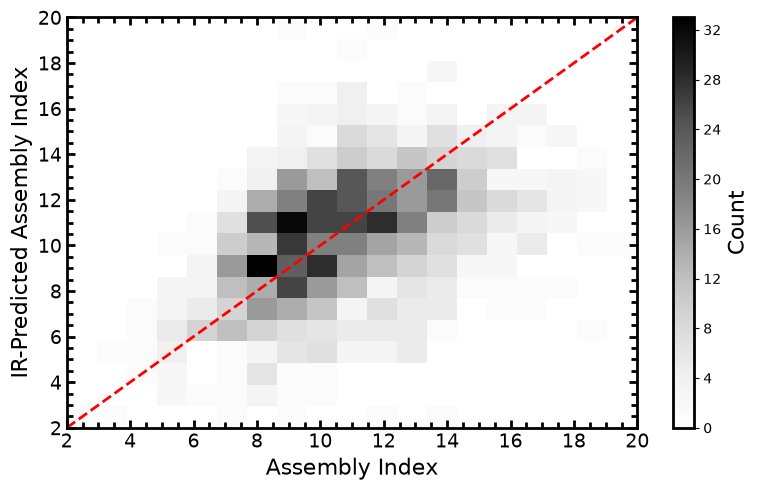

In [11]:
# Restrict predictions to the observed range before plotting.
mask = (ai_pred >= min(ai_obs)) & (ai_pred <= max(ai_obs))
ai_obs = ai_obs[mask]
ai_pred = ai_pred[mask]

fig, ax = att.plot_heatmap(
    ai_obs, ai_pred,
    "Assembly Index", "IR-Predicted Assembly Index",
    nbins=(len(set(ai_obs)), len(set(ai_pred))),
    c_map='Greys',
)
x_line = np.linspace(min(ai_obs), max(ai_obs), 2)
plt.plot(x_line, x_line, color='red', linestyle='--', linewidth=2)
plt.savefig("ir_ai_correlation_heatmap.svg")
plt.savefig("ir_ai_correlation_heatmap.png", dpi=300)
plt.show()

*Observed against predicted assembly index across the dataset. The predicted value comes from a linear model on IR peak count alone.*

In [12]:
print(f"Total wall time: {time.perf_counter() - _t_start:.1f} s")

Total wall time: 22.6 s


## Related documentation

* [Spectroscopy and mass spectrometry](https://assemblytheorytools.readthedocs.io/en/latest/guide/mass_spectrometry.html) — the IR route in detail.
* [Complexity scores](https://assemblytheorytools.readthedocs.io/en/latest/guide/complexity.html) — correlation statistics.